# aule — Spatial verification & advanced plots

This notebook covers two newer additions: `aule.metrics.spatial_verification` (neighborhood-based and multivariate verification metrics that go beyond simple pixel matching) and `aule.plots.advanced` (Hovmoller diagrams, CDF comparison, spectral density plots, and multi-panel time evolution snapshots).

In [1]:
!pip install -q aule

## Fractions Skill Score (FSS)

Pixel-wise metrics like IoU heavily penalize small spatial displacement: if a model predicts a rain event one pixel to the left of where it actually occurred, IoU can drop to near zero even though the forecast was nearly perfect. FSS instead compares the *local neighborhood fraction* of event pixels at a chosen window size, making it tolerant of exactly this kind of displacement error. It is the standard verification metric for precipitation nowcasting.

In [2]:
import numpy as np

np.random.seed(11)

# a small rectangular "event" blob (e.g. a rain cell)
gt = np.zeros((48, 48, 1))
gt[18:24, 18:24] = 2.0

# the prediction has the same blob, just shifted by a couple of pixels
pred_shifted = np.zeros((48, 48, 1))
pred_shifted[20:26, 20:26] = 2.0

from aule.metrics import iou, fractions_skill_score

print('IoU (harshly penalizes displacement):', iou(gt, pred_shifted))
print('FSS, small window (still strict):    ', fractions_skill_score(gt, pred_shifted, threshold=1.0, window=3))
print('FSS, larger window (more tolerant):  ', fractions_skill_score(gt, pred_shifted, threshold=1.0, window=15))

IoU (harshly penalizes displacement): 0.2857142857142857
FSS, small window (still strict):     0.6124763705103969
FSS, larger window (more tolerant):   0.9085740153915799


## Energy score: the multivariate CRPS

`aule.metrics.crps` scores each pixel independently, ignoring whether the ensemble correctly captures *joint* structure (e.g. spatial coherence — are errors at neighboring pixels correlated the way they should be?). The energy score treats an entire spatial/channel slice as one multivariate forecast vector, rewarding ensembles that get the joint distribution right, not just each marginal.

In [3]:
from aule.metrics import energy_score

gt_field = np.random.rand(32, 32, 1)
ensemble = gt_field[np.newaxis] + np.random.normal(0, 0.1, (20, 32, 32, 1))

score = energy_score(gt_field, ensemble)
print('Energy score:', score)

# sanity check: a perfect deterministic ensemble should score 0
perfect_ensemble = np.stack([gt_field] * 20, axis=0)
print('Energy score (perfect ensemble):', energy_score(gt_field, perfect_ensemble))

Energy score: 1.0447506141521994
Energy score (perfect ensemble): 0.0


## Hovmoller diagram

A Hovmoller diagram puts time on one axis and a single spatial dimension (latitude or longitude, averaged over the other) on the other, colored by value. It is the classic way to spot propagating features over time — traveling waves, monsoon progression, a cold front moving through — that a single spatial snapshot would never reveal.

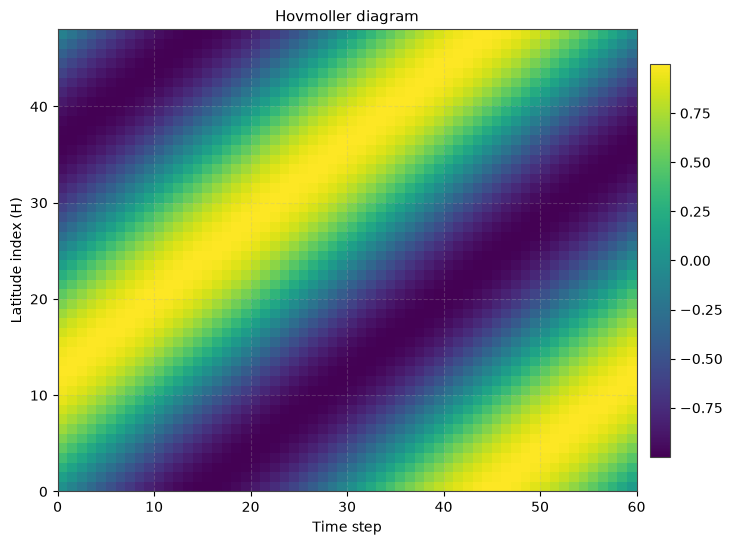

In [4]:
H, W, T = 48, 48, 60
lat_idx = np.arange(H).reshape(H, 1, 1, 1)
t_idx = np.arange(T).reshape(1, 1, 1, T)

# simulate a feature that propagates northward over time (a traveling wave)
wave = np.sin(2 * np.pi * (lat_idx / H - t_idx / T))
data = np.broadcast_to(wave, (H, W, 1, T)).copy()

from aule.plots import plot_hovmoller

fig, ax = plot_hovmoller(data, axis='lat', data_format='hwct')

## CDF comparison

`plot_cdf_comparison` overlays the empirical cumulative distribution functions of ground truth and prediction directly, complementing `aule.plots.plot_qq`. It makes it easy to see exactly where in the value range a model over- or under-represents probability mass — and pairs naturally with `aule.metrics.quantile_mapping_bias`, which measures the same gap numerically.

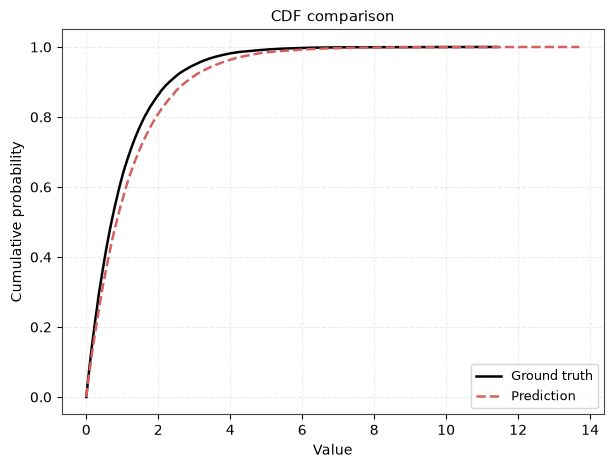

In [5]:
precip_gt   = np.random.exponential(1.0, (8, 64, 64, 1))
precip_pred = precip_gt * 1.2

from aule.plots import plot_cdf_comparison

fig, ax = plot_cdf_comparison(precip_gt, precip_pred)

## Spectral density plot

This visualizes the same radially-averaged power spectrum compared numerically by `aule.metrics.psd_radial_error`, on a log-log scale. It's a quick way to see at which spatial frequencies a model loses power (excessive smoothing, usually a flattened high-frequency tail) or gains spurious power (checkerboard artifacts, usually a spike at a specific frequency).

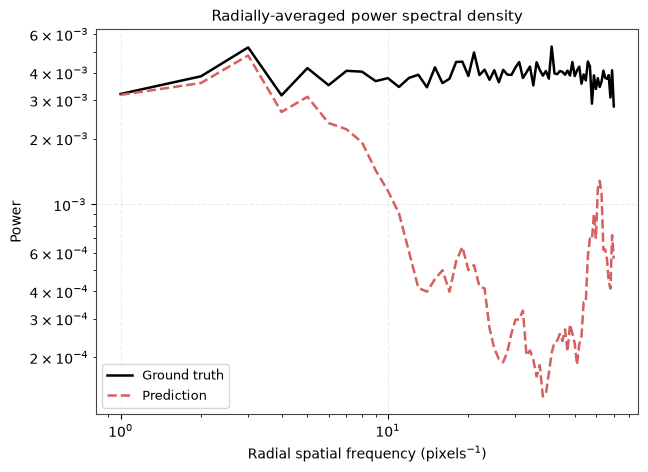

In [6]:
gt_field = np.random.rand(64, 64, 1)
# simulate an overly-smooth prediction (a common symptom of MSE-trained models)
from scipy.ndimage import uniform_filter
pred_smooth = uniform_filter(gt_field[:, :, 0], size=5)[:, :, np.newaxis]

from aule.plots import plot_spectral_density

fig, ax = plot_spectral_density(gt_field, pred_smooth)

## Multi-panel time evolution

`plot_time_evolution` shows ground truth (top row) and prediction (bottom row) side by side at several time steps on a shared color scale — useful for spotting whether forecast quality degrades over a sequence (a common issue in autoregressive forecasting models).

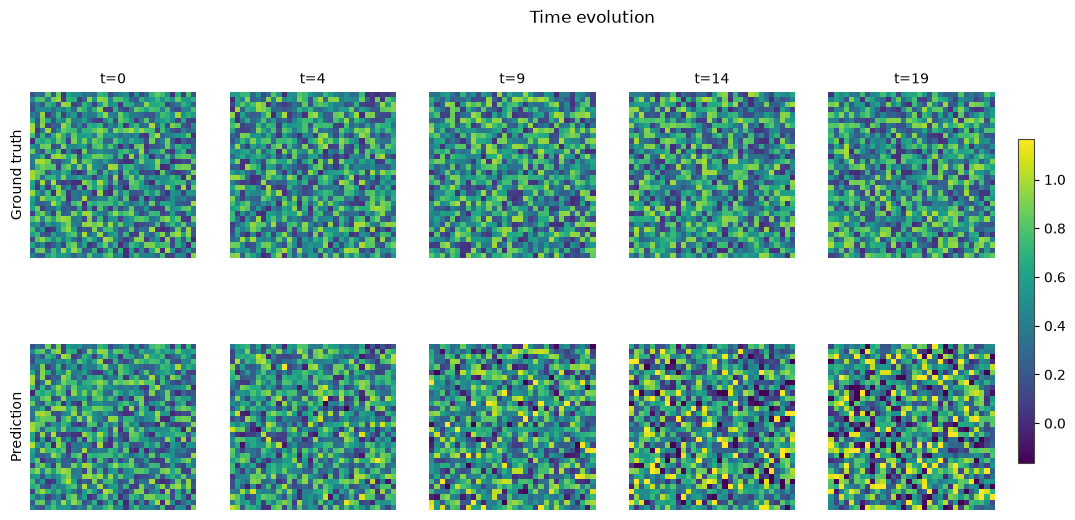

In [7]:
gt_seq = np.random.rand(32, 32, 1, 20)
# simulate degrading forecast quality over time (e.g. error accumulation)
noise_growth = np.linspace(0.02, 0.3, 20).reshape(1, 1, 1, 20)
pred_seq = gt_seq + np.random.normal(0, 1, gt_seq.shape) * noise_growth

from aule.plots import plot_time_evolution

fig, axes = plot_time_evolution(gt_seq, pred_seq, data_format='hwct')